# 1. Problématique

**Objectif :** 

- **Question claire :** Quels types de jeux vidéo réussissent le mieux, et peut-on prévoir le succès d’un nouveau jeu à partir de ses caractéristiques ?
- **Contexte** : Un dataset de +64000 jeux vidéos sur 40 ans.

- **Objectif du projet :** Déterminer quels types de jeux vidéos réussissent le mieux pour prévoir le succès d'un jeu donné.
- **Définition de la target supervisée*** : 



In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score

FILE = "Video_Games.csv" 
df = pd.read_csv(FILE)


# 2. Dataset

**Sources des données :** 

- **Description des variables** 
- **Justification du choix**






# 3. EDA

- **Analyse des distributions** 
- **Visualisations** 
- **Premiers insights**






In [2]:
df.head()

,img,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update
0,/games/boxart/full_6510540AmericaFrontccc.jpg,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,20.32,6.37,0.99,9.85,3.12,17-09-2013,NaN
1,/games/boxart/full_5563178AmericaFrontccc.jpg,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,6.06,0.60,9.71,3.02,18-11-2014,03-01-2018
2,/games/boxart/827563ccc.jpg,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,16.15,8.41,0.47,5.49,1.78,28-10-2002,NaN
3,/games/boxart/full_9218923AmericaFrontccc.jpg,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,NaN,15.86,9.06,0.06,5.33,1.42,17-09-2013,NaN
4,/games/boxart/full_4990510AmericaFrontccc.jpg,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1,15.09,6.18,0.41,6.05,2.44,06-11-2015,14-01-2018


In [3]:
df.tail()

,img,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update
64011,/games/boxart/full_2779838AmericaFrontccc.jpg,XBlaze Lost: Memories,PC,Visual Novel,Aksys Games,Arc System Works,NaN,NaN,NaN,NaN,NaN,NaN,11-08-2016,28-01-2019
64012,/games/boxart/full_8031506AmericaFrontccc.jpg,"Yoru, Tomosu",PS4,Visual Novel,Nippon Ichi Software,Nippon Ichi Software,NaN,NaN,NaN,NaN,NaN,NaN,30-07-2020,09-05-2020
64013,/games/boxart/full_6553045AmericaFrontccc.jpg,"Yoru, Tomosu",NS,Visual Novel,Nippon Ichi Software,Nippon Ichi Software,NaN,NaN,NaN,NaN,NaN,NaN,30-07-2020,09-05-2020
64014,/games/boxart/full_6012940JapanFrontccc.png,Yunohana SpRING! ~Mellow Times~,NS,Visual Novel,Idea Factory,Otomate,NaN,NaN,NaN,NaN,NaN,NaN,28-02-2019,24-02-2019
64015,/games/boxart/default.jpg,Yurukill: The Calumniation Games,PS4,Visual Novel,Unknown,G.rev Ltd.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29-09-2023


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64016 entries, 0 to 64015
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   img           64016 non-null  object 
 1   title         64016 non-null  object 
 2   console       64016 non-null  object 
 3   genre         64016 non-null  object 
 4   publisher     64016 non-null  object 
 5   developer     63999 non-null  object 
 6   critic_score  6678 non-null   float64
 7   total_sales   18922 non-null  float64
 8   na_sales      12637 non-null  float64
 9   jp_sales      6726 non-null   float64
 10  pal_sales     12824 non-null  float64
 11  other_sales   15128 non-null  float64
 12  release_date  56965 non-null  object 
 13  last_update   17879 non-null  object 
dtypes: float64(6), object(8)
memory usage: 6.8+ MB


In [5]:
df.describe()

,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales
count,6678.000000,18922.000000,12637.000000,6726.000000,12824.000000,15128.000000
mean,7.220440,0.349113,0.264740,0.102281,0.149472,0.043041
std,1.457066,0.807462,0.494787,0.168811,0.392653,0.126643
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6.400000,0.030000,0.050000,0.020000,0.010000,0.000000
50%,7.500000,0.120000,0.120000,0.040000,0.040000,0.010000
75%,8.300000,0.340000,0.280000,0.120000,0.140000,0.030000
max,10.000000,20.320000,9.760000,2.130000,9.850000,3.120000


In [6]:
df.shape

(64016, 14)

In [7]:
df.isna().sum()

img                 0
title               0
console             0
genre               0
publisher           0
developer          17
critic_score    57338
total_sales     45094
na_sales        51379
jp_sales        57290
pal_sales       51192
other_sales     48888
release_date     7051
last_update     46137
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

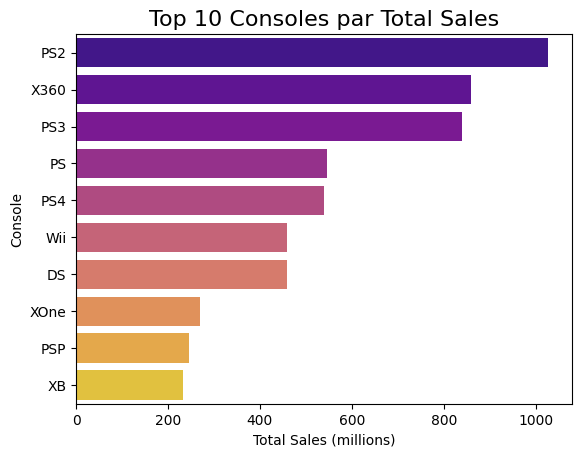

In [9]:
console_sales = df.groupby('console')['total_sales'].sum().sort_values(ascending=False).head(10)
plt.figure()
sns.barplot(x=console_sales.values, y=console_sales.index, hue=console_sales.index, palette="plasma")
plt.title("Top 10 Consoles par Total Sales", fontsize=16)
plt.xlabel("Total Sales (millions)")
plt.ylabel("Console")
plt.show()

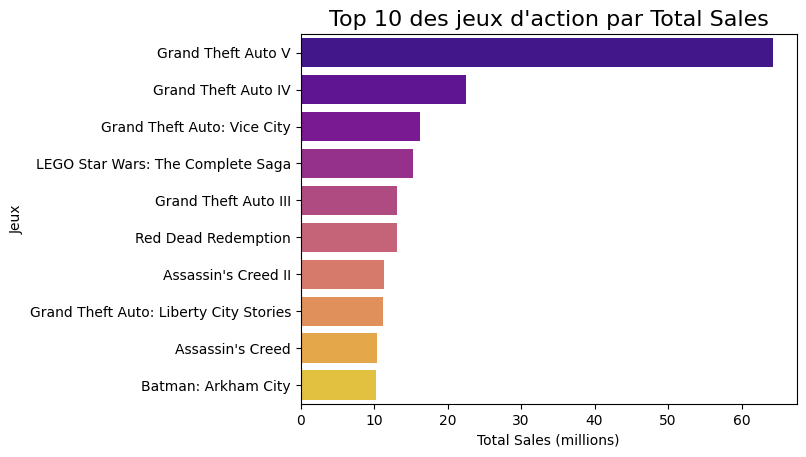

In [10]:
dfActions = df[df['genre'] == 'Action'].groupby('title')['total_sales'].sum().sort_values(ascending=False).head(10)
plt.figure()
sns.barplot(x=dfActions.values, y=dfActions.index, hue=dfActions.index, palette="plasma")
plt.title("Top 10 des jeux d'action par Total Sales", fontsize=16)
plt.xlabel("Total Sales (millions)")
plt.ylabel("Jeux")
plt.show()

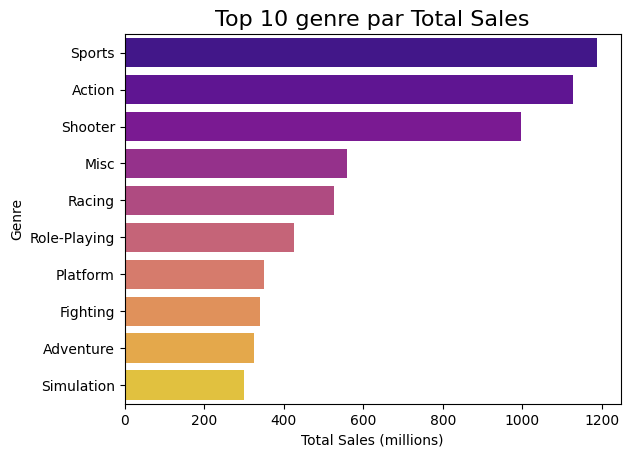

In [11]:
genre_sales = df.groupby('genre')['total_sales'].sum().sort_values(ascending=False).head(10)
plt.figure()
sns.barplot(x=genre_sales.values, y=genre_sales.index, hue=genre_sales.index, palette="plasma")
plt.title("Top 10 genre par Total Sales", fontsize=16)
plt.xlabel("Total Sales (millions)")
plt.ylabel("Genre")
plt.show()

# 4.Data Cleaning
- **Gestion des valeurs manquantes**
- **Traitement des outliers**
- **Feature engineering**

In [12]:
df["release_date"] = pd.to_datetime(df["release_date"], format="%d-%m-%Y")
df["last_update"] = pd.to_datetime(df["last_update"], format="%d-%m-%Y")

In [13]:
df.dtypes

img                     object
title                   object
console                 object
genre                   object
publisher               object
developer               object
critic_score           float64
total_sales            float64
na_sales               float64
jp_sales               float64
pal_sales              float64
other_sales            float64
release_date    datetime64[ns]
last_update     datetime64[ns]
dtype: object

In [14]:
df.head(10)

,img,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update
0,/games/boxart/full_6510540AmericaFrontccc.jpg,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,20.32,6.37,0.99,9.85,3.12,2013-09-17,NaT
1,/games/boxart/full_5563178AmericaFrontccc.jpg,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,6.06,0.60,9.71,3.02,2014-11-18,2018-01-03
2,/games/boxart/827563ccc.jpg,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,16.15,8.41,0.47,5.49,1.78,2002-10-28,NaT
3,/games/boxart/full_9218923AmericaFrontccc.jpg,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,NaN,15.86,9.06,0.06,5.33,1.42,2013-09-17,NaT
4,/games/boxart/full_4990510AmericaFrontccc.jpg,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1,15.09,6.18,0.41,6.05,2.44,2015-11-06,2018-01-14
5,/games/boxart/full_call-of-duty-modern-warfare...,Call of Duty: Modern Warfare 3,X360,Shooter,Activision,Infinity Ward,8.7,14.82,9.07,0.13,4.29,1.33,2011-11-08,NaT
6,/games/boxart/full_call-of-duty-black-ops_5Ame...,Call of Duty: Black Ops,X360,Shooter,Activision,Treyarch,8.8,14.74,9.76,0.11,3.73,1.14,2010-11-09,NaT
7,/games/boxart/full_4653215AmericaFrontccc.jpg,Red Dead Redemption 2,PS4,Action-Adventure,Rockstar Games,Rockstar Games,9.8,13.94,5.26,0.21,6.21,2.26,2018-10-26,2018-11-02
8,/games/boxart/full_1977964AmericaFrontccc.jpg,Call of Duty: Black Ops II,X360,Shooter,Activision,Treyarch,8.4,13.86,8.27,0.07,4.32,1.20,2012-11-13,2018-04-07
9,/games/boxart/full_4649679AmericaFrontccc.png,Call of Duty: Black Ops II,PS3,Shooter,Activision,Treyarch,8.0,13.80,4.99,0.65,5.88,2.28,2012-11-13,2018-04-07


In [15]:
df['critic_score'] = df['critic_score'].fillna(df['critic_score'].median())
df.isna().sum()

img                 0
title               0
console             0
genre               0
publisher           0
developer          17
critic_score        0
total_sales     45094
na_sales        51379
jp_sales        57290
pal_sales       51192
other_sales     48888
release_date     7051
last_update     46137
dtype: int64

In [16]:
df = df.drop(columns=['img','na_sales', 'jp_sales', 'pal_sales', 'other_sales', 'last_update'])

In [17]:
df = df.dropna(subset=['total_sales'])

In [18]:
df.isna().sum()

title            0
console          0
genre            0
publisher        0
developer        4
critic_score     0
total_sales      0
release_date    90
dtype: int64

In [19]:
df = df.dropna(subset=['developer', 'release_date'])

In [20]:
print(df['critic_score'].min(), df['critic_score'].max())

1.0 10.0


# 5.Machine Learning Non Supervisé
- **Préparation des features**
- **Scaling**
- **KMeans**
- **Choix du nombre de clusters avec Elbow et Silhouette**
-  **Interprétation des clusters**

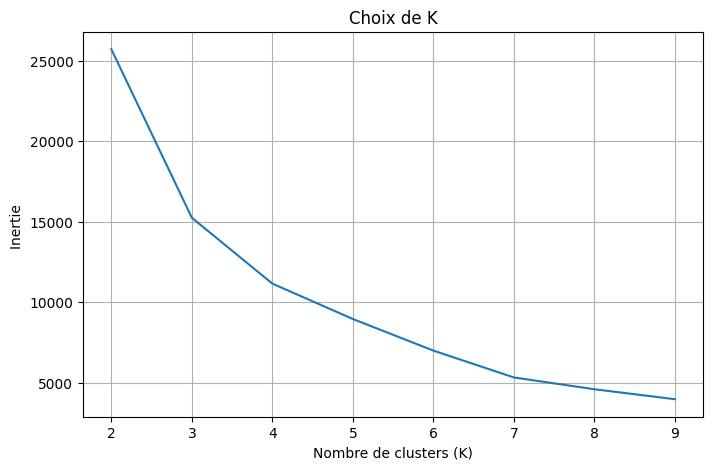

In [21]:
features = ['critic_score', 'total_sales']
scaler = StandardScaler()

X = scaler.fit_transform(df[features])
inertia = []
for k in range(2,10):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertia.append(km.inertia_)
    
plt.figure(figsize=(8, 5))
plt.plot(range(2, 10), inertia)
plt.xlabel('Nombre de clusters (K)')
plt.ylabel('Inertie ')
plt.title('Choix de K')
plt.grid(True)
plt.show()

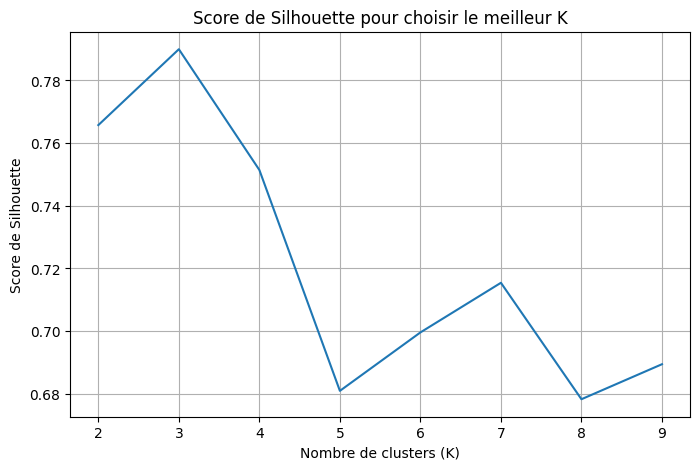

In [22]:
silhouette_scores = []
for k in range(2,10):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X) 
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)


plt.figure(figsize=(8, 5))
plt.plot(range(2, 10), silhouette_scores)
plt.xlabel('Nombre de clusters (K)')
plt.ylabel('Score de Silhouette')
plt.title('Score de Silhouette pour choisir le meilleur K')
plt.grid(True)
plt.show()

In [23]:
best_k = 3

modele_kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
modele_kmeans.fit(X)
df['cluster'] = modele_kmeans.labels_
moyennes_clusters = df.groupby('cluster')[features].mean()
print(moyennes_clusters)
print(df['cluster'].value_counts())

         critic_score  total_sales
cluster                           
0            7.532237     0.257966
1            8.171875     4.299712
2            5.146300     0.315351
cluster
0    17359
2     1054
1      416
Name: count, dtype: int64


# 6.Machine Learning Supervisé
- **Définition de la target**
- **Entrainement d'un modèle**
- **Evaluation des performances**
- **Interprétation**
  

# 7.Conclusion
- **Résultats principaux**
- **Limites du projet**
- **Pistes d'amélioration**